In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from flexcraft.data.data import DesignData
from flexcraft.files import PDBFile
from flexcraft.pipelines.tcr.utils import *
from flexcraft.sequence.aa_codes import AF2_CODE, decode, PMPNN_CODE
import anarci
from Bio import Align
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import tempfile
from flexcraft.pipelines.tcr.tcrdock import *
from scipy.spatial.transform import Rotation
import jax.numpy as jnp

In [2]:
%matplotlib widget


In [3]:
tmp = tempfile.TemporaryDirectory(prefix="geometry_devel_")
tmpdir = Path(tmp.name)
data_dir = Path("../../../Data/input_data/")

In [4]:
def download_structure(test_id, *args, **kwargs):
    return (data_dir/test_id).with_suffix(".pdb")

for test_id in [
    "5BS0",
    "3QDG",
    "3GSN",
    "7N2R",
    "5EU6",
    "1OGA",
    "7RRG",
    "7OW6",]:
    clean_chothia(download_structure(test_id,out_dir=data_dir.__str__()))

New plot axis
Calculating Axes
Calculating Axes
Calculating Axes


<Axes3D: title={'center': 'Orientation Axes'}, xlabel='X Label', ylabel='Y Label', zlabel='Z Label'>

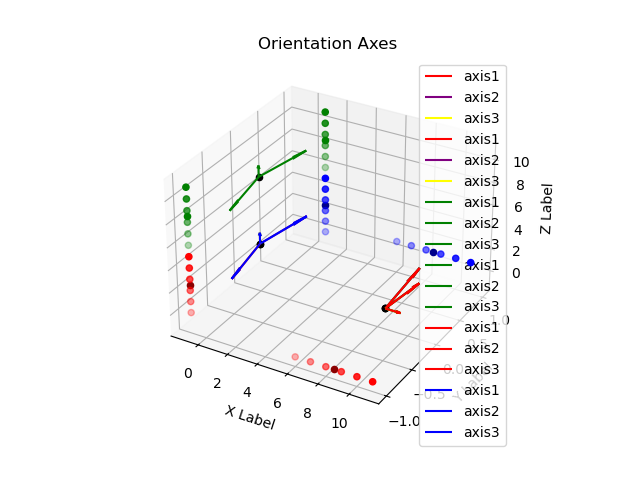

In [5]:
# test axis relocation
a = (np.concatenate([np.arange(6,12)[:,None],np.full((6,2),1)], axis=-1),np.concatenate([np.arange(6,12)[:,None],np.full((6,2),-1)], axis=-1))
b = (np.concatenate([np.full((6,2),1),np.arange(0,6)[:,None]], axis=-1),np.concatenate([np.full((6,2),-1),np.arange(0,6)[:,None]], axis=-1))
c = (np.concatenate([np.full((6,2),1),np.arange(6,12)[:,None]], axis=-1),np.concatenate([np.full((6,2),-1),np.arange(6,12)[:,None]], axis=-1))

kwargs = dict(lim=(-2,5),plot_points=True)
ax = plot_axes(a=a[0], b=a[1], **kwargs)
plot_axes(a=b[0], b=b[1], ax=ax, **kwargs)
plot_axes(a=c[0], b=c[1], ax=ax, **kwargs, color="green")
op = get_ax_op(
    *get_axes(b[0], b[1]),
    *get_axes(a[0], a[1]),
    )
plot_axes(*apply_ax_op(*get_axes(b[0], b[1]), op=op), ax=ax, color="green", **kwargs)

op2 = get_ax_op(
    *get_axes(c[0], c[1]),
    *get_axes(a[0], a[1]),
    )
plot_axes(*apply_ax_op(*get_axes(c[0], c[1]), op=op2), ax=ax,color="red", **kwargs)
plot_axes(*rev_ax_op(*apply_ax_op(*get_axes(c[0], c[1]), op=op2), op=op), ax=ax, **kwargs, color="blue")


In [6]:
#def center_atom(atom_positions:np.ndarray, axes:np.ndarray, center:np.ndarray):
#    return atom_positions-center


New plot axis
Calculating Axes
Calculating Axes
Calculating Axes
Calculating Axes


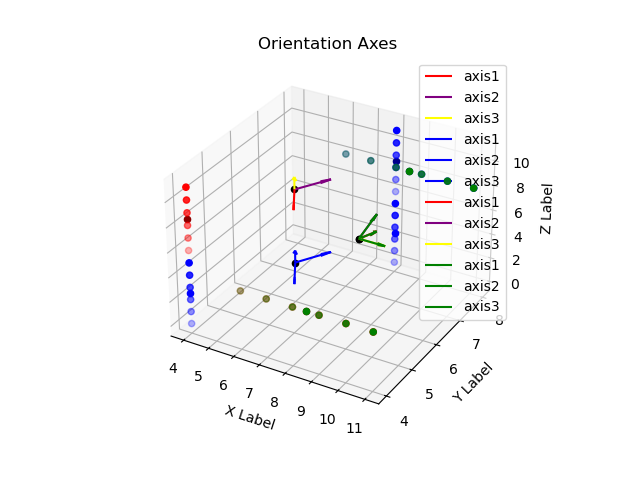

In [7]:
# test point relocation
a = np.concatenate([np.arange(6,12)[:,None],np.full((6,2),8)], axis=-1, dtype=np.float32),np.concatenate([np.arange(6,12)[:,None],np.full((6,2),4)], axis=-1, dtype=np.float32)
a = np.concatenate(a, axis=0)
b = np.concatenate([np.full((6,2),8),np.arange(0,6)[:,None]], axis=-1, dtype=np.float32),np.concatenate([np.full((6,2),4),np.arange(0,6)[:,None]], axis=-1, dtype=np.float32)
b = np.concatenate(b, axis=0)
c = np.concatenate([np.full((6,2),8),np.arange(6,12)[:,None]], axis=-1, dtype=np.float32),np.concatenate([np.full((6,2),4),np.arange(6,12)[:,None]], axis=-1, dtype=np.float32)
c = np.concatenate(c, axis=0)
d = np.concatenate([np.full((6,1),8),np.arange(6,12)[:,None],np.full((6,1),8)], axis=-1, dtype=np.float32),np.concatenate([np.full((6,1),4),np.arange(6,12)[:,None],np.full((6,1),4)], axis=-1, dtype=np.float32)
d = np.concatenate(d, axis=0)

kwargs = dict(lim=(-2,5),plot_points=True)
ax = plot_axes(a=a[:6], b=a[6:], **kwargs, color=False)
plot_axes(a=b[:6], b=b[6:], ax=ax, **kwargs, color="blue")
plot_axes(a=c[:6], b=c[6:], ax=ax, **kwargs)
#plot_axes(a=d[:6], b=d[6:], ax=ax, **kwargs)

op = get_ax_op(
    *get_axes(b[:6], b[6:]),
    *get_axes(a[:6], a[6:]),
    )

b1 = apply_atom_op(b, op=op).squeeze()

plot_axes(a=b1[:6], b=b1[6:], ax=ax, color="green", **kwargs, )
op = get_ax_op(
    *get_axes(c[:6], c[6:]),
    *get_axes(a[:6], a[6:]),
    )
b2 = rev_atom_op(b1, op=op)
#plot_axes(a=b2[:6], b=b2[6:], ax=ax, **kwargs, color="red")


ERROR:2026-05-13 21:31:36,955:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/ntbiotech/.miniforge/envs/flexcraft_2/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/ntbiotech/.miniforge/envs/flexcraft_2/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/ntbiotech/.miniforge/envs/flexcraft_2/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


{0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
No numbering found for chain 0!
No numbering found for chain 1!
No numbering found for chain 2!
Setting chain 3 to A!
Setting chain 4 to B!
Classified chains [0] as MHC/antigen chains
Alignment score: 1082.0
target            0 -PHSMRYFETAVSRPGLEEPRYISVGYVDNKEFVRFDSDAENPRYEPRAPWMEQEGPEYW
                  0 -.||||||.|.|||||..|||.|.|||||...||||||||..||.||||||.||||||||
query             0 GSHSMRYFHTSVSRPGRGEPRFITVGYVDDTLFVRFDSDAASPREEPRAPWIEQEGPEYW

target           59 ERETQKAKGQEQWFRVSLRNLLGYYNQSAGGSHTLQQMSGCDLGSDWRLLRGYLQFAYEG
                 60 .||||..|...|..|..||.||.|||||..||||||.|.|||.|.|.||||||.|.||.|
query            60 DRETQISKAKAQTDREDLRTLLRYYNQSEAGSHTLQNMYGCDVGPDGRLLRGYHQDAYDG

target          119 RDYIALNEDLKTWTAADMAAQITRRKWEQSGAAEHYKAYLEGECVEWLHRYLKNGNATLL
                120 .|||||||||..|||||.|||||.||||....||...|||||||||||.|||.||..||.
query           120 KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGECVEWLRRYLENGKETLQ

target          179 RTDSPKAHV

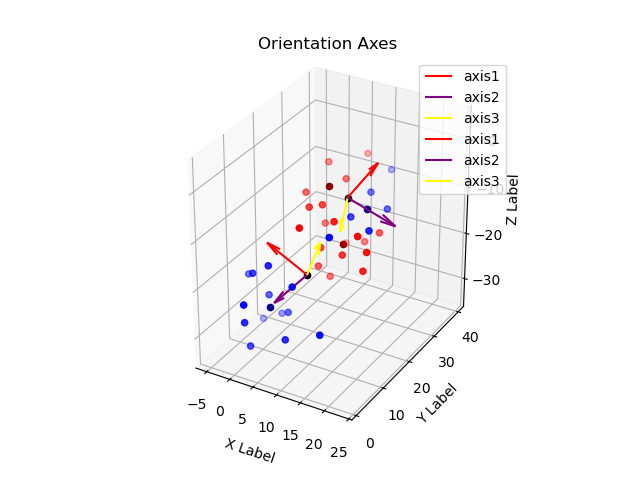

In [8]:
test_id = "9PBH"
test_file = download_structure(test_id, out_dir=tmpdir.__str__())
test_file = clean_chothia(test_file)
mhc1_design = PDBFile(path=test_file).to_data()
mhc1_design,d = convert_chains(mhc1_design)
mhc1_design, params_1 = number_anarci(mhc1_design, mhc_class=1)
positions_1 = get_mhc1_positions(mhc1_design, params_1)
ax = plot_axes(
    a=get_mhc_coords(mhc1_design, positions_1)[:6],
    b=get_mhc_coords(mhc1_design, positions_1)[6:],
    ref=get_mhc_ref(mhc1_design, params_1),
    plot_points=True,
    normalize=10
)
ax = plot_axes(
    a=get_tcr_coords(mhc1_design, params_1["tcr_chain_index"])[:13],
    b=get_tcr_coords(mhc1_design, params_1["tcr_chain_index"])[13:],
    ref=get_tcr_ref(mhc1_design, params_1),
    ax=ax,
    plot_points=True,
    normalize=10
    )
ax.set_aspect("equal")

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
No numbering found for chain 0!
No numbering found for chain 1!
No numbering found for chain 2!
Setting chain 3 to A!
Setting chain 4 to B!
Classified chains [0 1] as MHC/antigen chains
Found hit with evalue 5.49e-51
Found hit with evalue 1.97e-60
New plot axis
Calculating Axes
Before correction:  [-0.6812738   0.60970262  0.40512807] [-0.71988924 -0.45764856 -0.52184028]
Correcting to [ 0.69424176 -0.6030466  -0.39289078]
Angle is 178.90953479419937
After correction:  [ 0.6812738  -0.60970262 -0.40512807] [0.71988924 0.45764856 0.52184028]
Calculating Axes
Before correction:  [-0.70328864  0.66480702  0.25182679] [ 0.44001065  0.68529868 -0.58030712]
Correcting to [-0.7701016  0.4944838  0.4030253]
Angle is 13.631255918013924
After correction:  [-0.70328864  0.66480702  0.25182679] [ 0.44001065  0.68529868 -0.58030712]


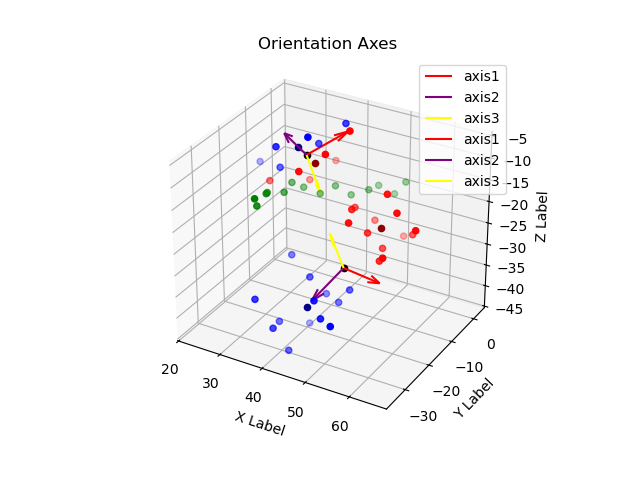

In [9]:
test_id = "8VD2"
mhc2_design_path = clean_chothia(download_structure(test_id,out_dir=tmpdir.__str__()))
mhc2_design = PDBFile(path=mhc2_design_path).to_data()
mhc2_design, d = convert_chains(mhc2_design)
mhc2_design, params_2 = number_anarci(mhc2_design, mhc_class=2)
positions_2 = get_mhc2_positions(
    design=mhc2_design,
    params=params_2,
    db_files={
        "A":Path("/home/ntbiotech/Documents/Current_projects/BinderDesign/TCRdock/tcrdock/db/both_class_2_A_chains_v2.fasta"),
        "B":Path("/home/ntbiotech/Documents/Current_projects/BinderDesign/TCRdock/tcrdock/db/both_class_2_B_chains_v2.fasta")
    },
    blast_exe=Path("../../../ncbi-blast-2.17.0+/bin"),
    )
ax = plot_axes(
    a=get_mhc_coords(mhc2_design, positions_2["A"]),
    b=get_mhc_coords(mhc2_design, positions_2["B"]),
    ref=get_mhc_ref(mhc2_design, params_2),
    plot_points=True,
    normalize=10
)
ax.scatter(*get_mhc_ref(mhc2_design, params_2).T, color="green")
ax = plot_axes(
    a=get_tcr_coords(mhc2_design, params_2["tcr_chain_index"])[:13],
    b=get_tcr_coords(mhc2_design, params_2["tcr_chain_index"])[13:],
    ref=get_tcr_ref(mhc2_design, params_2),
    ax=ax,
    #lim=(-1,1),
    plot_points=True,
    normalize=10,
    #color="blue"
    )
ax.set_aspect("equal")

In [10]:
tcr_axes, tcr_center = get_axes(
    get_tcr_coords(mhc1_design, params_1["tcr_chain_index"])[:13],
    get_tcr_coords(mhc1_design, params_1["tcr_chain_index"])[13:],
)
mhc_positions = get_mhc1_positions(
    design=mhc1_design,
    params=params_1,
    )
mhc_coords_0 = get_mhc_coords(
    design=mhc1_design,
    positions=mhc_positions[:6])
mhc_coords_1 = get_mhc_coords(
    design=mhc1_design,
    positions=mhc_positions[6:])
mhc_axes, mhc_center = get_axes(
    mhc_coords_0,
    mhc_coords_1
)
op1 = get_ax_op(
        tcr_axes,
        tcr_center,
        mhc_axes,
        mhc_center
)
axes, center = apply_ax_op(
    tcr_axes,
    tcr_center,
    op1
)
test_axes_operations(
    axes1=tcr_axes,
    center1=tcr_center,
    axes2=mhc_axes,
    center2=mhc_center,
    get_ax_op=get_ax_op,
    apply_ax_op=apply_ax_op)

Alignment score: 1082.0
target            0 -PHSMRYFETAVSRPGLEEPRYISVGYVDNKEFVRFDSDAENPRYEPRAPWMEQEGPEYW
                  0 -.||||||.|.|||||..|||.|.|||||...||||||||..||.||||||.||||||||
query             0 GSHSMRYFHTSVSRPGRGEPRFITVGYVDDTLFVRFDSDAASPREEPRAPWIEQEGPEYW

target           59 ERETQKAKGQEQWFRVSLRNLLGYYNQSAGGSHTLQQMSGCDLGSDWRLLRGYLQFAYEG
                 60 .||||..|...|..|..||.||.|||||..||||||.|.|||.|.|.||||||.|.||.|
query            60 DRETQISKAKAQTDREDLRTLLRYYNQSEAGSHTLQNMYGCDVGPDGRLLRGYHQDAYDG

target          119 RDYIALNEDLKTWTAADMAAQITRRKWEQSGAAEHYKAYLEGECVEWLHRYLKNGNATLL
                120 .|||||||||..|||||.|||||.||||....||...|||||||||||.|||.||..||.
query           120 KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGECVEWLRRYLENGKETLQ

target          179 RTDSPKAHVTHHPRSKGEVTLRCWALGFYPADITLTWQLNGEELTQDMELVETRPAGDGT
                180 |.|.||.||||||.|..|.||||||||||||.||||||..||..|||.||||||||||.|
query           180 RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT



In [11]:
op1 = parse_structure(mhc1_design,mhc_class=1)
op2 = parse_structure(mhc2_design,mhc_class=2)

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
No numbering found for chain 0!
No numbering found for chain 1!
No numbering found for chain 2!
Setting chain 3 to A!
Setting chain 4 to B!
Classified chains [0] as MHC/antigen chains
Before correction:  [-0.39113266  0.16857444 -0.904764  ] [ 0.91181999 -0.06243399 -0.40581561]
Correcting to [ 0.48326102 -0.14015855  0.8641842 ]
Angle is 174.0039332913032
After correction:  [ 0.39113266 -0.16857444  0.904764  ] [-0.91181999  0.06243399  0.40581561]
Alignment score: 1082.0
target            0 -PHSMRYFETAVSRPGLEEPRYISVGYVDNKEFVRFDSDAENPRYEPRAPWMEQEGPEYW
                  0 -.||||||.|.|||||..|||.|.|||||...||||||||..||.||||||.||||||||
query             0 GSHSMRYFHTSVSRPGRGEPRFITVGYVDDTLFVRFDSDAASPREEPRAPWIEQEGPEYW

target           59 ERETQKAKGQEQWFRVSLRNLLGYYNQSAGGSHTLQQMSGCDLGSDWRLLRGYLQFAYEG
                 60 .||||..|...|..|..||.||.|||||..||||||.|.|||.|.|.||||||.|.||.|
query            60 DRETQISKAKAQTDREDLRTLLRYYNQSEAGSHTLQNMYGCDVGPDGRLLRGYHQDAYDG

tar

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
No numbering found for chain 0!
No numbering found for chain 1!
No numbering found for chain 2!
Setting chain 3 to A!
Setting chain 4 to B!
Classified chains [0] as MHC/antigen chains
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
No numbering found for chain 0!
No numbering found for chain 1!
No numbering found for chain 2!
Setting chain 3 to A!
Setting chain 4 to B!
Classified chains [0] as MHC/antigen chains
Before correction:  [0.44795408 0.60734618 0.6561004 ] [ 0.44105314  0.48821899 -0.75306994]
Correcting to [0.34966782 0.54450595 0.76239467]
Angle is 9.051918214293837
After correction:  [0.44795408 0.60734618 0.6561004 ] [ 0.44105314  0.48821899 -0.75306994]
Alignment score: 1033.0
target            0 -PHSMRYFETAVSRPGLEEPRYISVGYVDNKEFVRFDSDAENPRYEPRAPWMEQEGPEYW
                  0 -.||||||.|.|||||..|||.|.|||||...||||||||.....||||||.||||||||
query             0 GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQKMEPRAPWIEQEGPEYW

target           59 ERETQKAKGQEQWFRVSLRNL

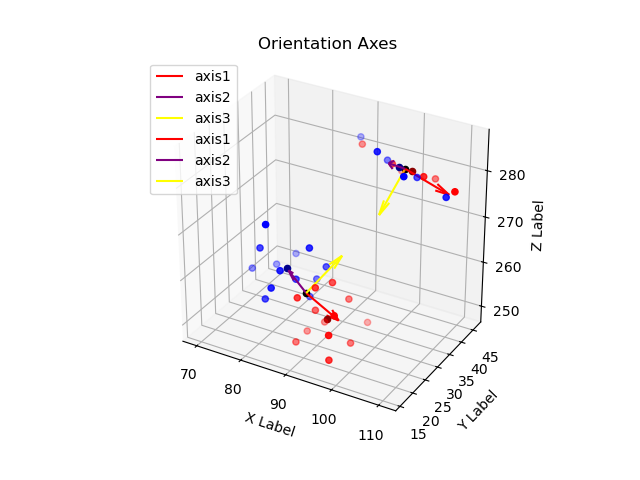

In [12]:
test_id = "5BS0"
test_design_path = clean_chothia(download_structure(test_id,out_dir=tmpdir.__str__()))
test_design = PDBFile(path=test_design_path).to_data()
test_design, d = convert_chains(test_design)
test_design, test_params = number_anarci(test_design, mhc_class=1)
test_op = parse_structure(test_design, mhc_class=1)
test_positions = get_mhc1_positions(test_design, test_params)
ax = plot_axes(
    a=get_mhc_coords(test_design, test_positions)[:6],
    b=get_mhc_coords(test_design, test_positions)[6:],
    ref=get_mhc_ref(test_design, test_params),
    plot_points=True,
    normalize=10
)
ax = plot_axes(
    a=get_tcr_coords(test_design, test_params["tcr_chain_index"])[:13],
    b=get_tcr_coords(test_design, test_params["tcr_chain_index"])[13:],
    ref=get_tcr_ref(test_design, test_params),
    ax=ax,
    plot_points=True,
    normalize=10
    )
ax.set_aspect("equal")

[3 4]
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
No numbering found for chain 0!
No numbering found for chain 1!
No numbering found for chain 2!
Setting chain 3 to A!
Setting chain 4 to B!
Classified chains [0] as MHC/antigen chains
Before correction:  [-0.39113266  0.16857444 -0.904764  ] [ 0.91181999 -0.06243399 -0.40581561]
Correcting to [ 0.48326102 -0.14015855  0.8641842 ]
Angle is 174.0039332913032
After correction:  [ 0.39113266 -0.16857444  0.904764  ] [-0.91181999  0.06243399  0.40581561]
Alignment score: 1082.0
target            0 -PHSMRYFETAVSRPGLEEPRYISVGYVDNKEFVRFDSDAENPRYEPRAPWMEQEGPEYW
                  0 -.||||||.|.|||||..|||.|.|||||...||||||||..||.||||||.||||||||
query             0 GSHSMRYFHTSVSRPGRGEPRFITVGYVDDTLFVRFDSDAASPREEPRAPWIEQEGPEYW

target           59 ERETQKAKGQEQWFRVSLRNLLGYYNQSAGGSHTLQQMSGCDLGSDWRLLRGYLQFAYEG
                 60 .||||..|...|..|..||.||.|||||..||||||.|.|||.|.|.||||||.|.||.|
query            60 DRETQISKAKAQTDREDLRTLLRYYNQSEAGSHTLQNMYGCDVGPDGRLLRGYHQDAYD

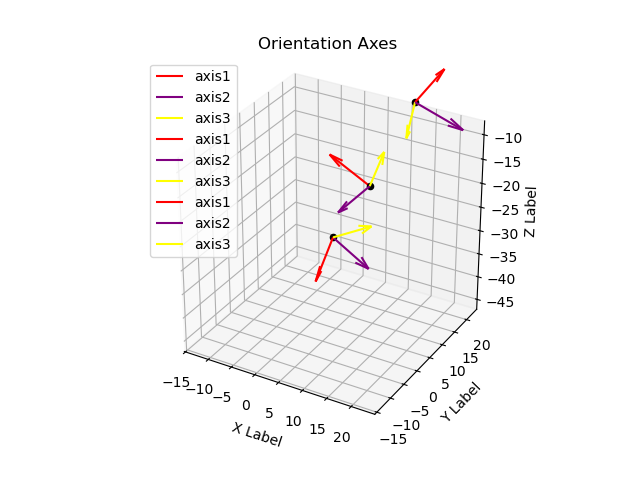

In [13]:
design = mhc1_design
op=test_op
design_op = None
params = params_1
chains=params["tcr_chain_index"]
print(chains)
x_factor=20
kwargs = dict(lim=(-1*x_factor,1*x_factor),plot_points=False, angle=None, normalize=.5*x_factor)#45*9)
mhc_class=1
out_design = apply_op_full_scaffold(design=design, op=op, chains=chains, mhc_class=mhc_class)

mhc_positions = get_mhc1_positions(
    design=design,
    params=params,
    )
mhc_coords_0 = get_mhc_coords(
    design=design,
    positions=mhc_positions[:6])
mhc_coords_1 = get_mhc_coords(
    design=design,
    positions=mhc_positions[6:])
mhc_axes, mhc_center = get_axes(
    mhc_coords_0,
    mhc_coords_1
)

mhc_ref = get_mhc_ref(design, params)
axis3, axis1 = check_direction(mhc_axes[:,-1], mhc_center, mhc_ref, mhc_axes[:,0])
mhc_axes[:,-1] = axis3
mhc_axes[:,0] = axis1

tcr_axes, tcr_center = get_axes(
    *[get_tcr_coords(design, np.array([chain])) for chain in chains]
    )
tcr_ref = get_tcr_ref(design, params)
axis3, axis1 = check_direction(tcr_axes[:,-1], tcr_center, tcr_ref, tcr_axes[:,0])
tcr_axes[:,-1] = axis3
tcr_axes[:,0] = axis1


c_axes, c_center = apply_ax_op(tcr_axes, tcr_center, op)

out_axes, out_center = get_axes(
    *[get_tcr_coords(out_design, np.array([chain])) for chain in chains]
    )
out_ref = get_tcr_ref(out_design, params)
axis3, axis1 = check_direction(out_axes[:,-1], tcr_center, tcr_ref, out_axes[:,0])
out_axes[:,-1] = axis3
out_axes[:,0] = axis1

print(out_design["atom_positions"].mean(axis=(0,1)),design["atom_positions"].mean(axis=(0,1)))
print("Maximum distance to template: ",(out_design["atom_positions"]-design["atom_positions"]).max())
#assert ~np.isclose(out_design["atom_positions"], design["atom_positions"], atol=1e-3).all()

fig = plt.figure()
ax = fig.add_subplot(projection='3d', )
ax.set_aspect("equal")
ax = plot_axes(axes=tcr_axes,center=tcr_center, ax=ax, **kwargs)
ax = plot_axes(axes=mhc_axes,center=mhc_center, ax=ax, **kwargs)
#ax = plot_axes(c_axes, c_center, ax=ax, **kwargs)
ax = plot_axes(out_axes, out_center, ax=ax,**kwargs)

In [14]:
def check_pose_direction(pose, ref):
    axes = pose[0]
    axis3, axis1 = check_direction(axes[:,-1], pose[1], ref, axes[:,0])
    axes[:,-1] = axis3
    axes[:,0] = axis1
    return (axes, pose[1])

def superpose(tcr_pose, mhc_pose, tcr_design, mhc_design, mhc_class=1):
    # tcr
    tcr_design, params = number_anarci(tcr_design, mhc_class=None)

    tcr_target_pose=get_axes(
        *[get_tcr_coords(
            tcr_design,
            np.array([chain])
        ) for chain in params["tcr_chain_index"]]
    )

    target_tcr_params = dict(tcr_chain_index=np.unique(tcr_design["chain_index"]))
    tcr_target_pose = check_pose_direction(tcr_target_pose, get_tcr_ref(tcr_design, target_tcr_params))
    tcr_op = get_ax_op(
        *tcr_target_pose,
        *tcr_pose,
    )
    tcr_design = translate_pose(tcr_design, target_pose=tcr_pose, current_pose=tcr_target_pose, chains=None)

    
    # mhc
    if mhc_class==1:
        chains = np.unique(mhc_design["chain_index"])
        chain_lengths = (mhc_design["chain_index"][:, None]==chains[None,:]).sum(axis=0)
        target_mhc_params = dict(mhc_chain_index=chains[np.argmax(chain_lengths)][None])
        mhc_positions = get_mhc1_positions(
            design=mhc_design,
            params=None,
            )
        mhc_coords_0 = get_mhc_coords(
            design=mhc_design,
            positions=mhc_positions[:6])
        mhc_coords_1 = get_mhc_coords(
            design=mhc_design,
            positions=mhc_positions[6:])
    elif mhc_class==2:
        chain_lengths = (mhc_design["chain_index"][:, None]==chains[None,:]).sum(axis=0)
        target_mhc_params = dict(mhc_chain_index=chains[np.argsort(chain_lengths)][::-1][:2])
        mhc_positions = get_mhc2_positions(
            design=mhc_design,
            params=target_mhc_params,
            db_files={
                "A":Path("/home/ntbiotech/Documents/Current_projects/BinderDesign/TCRdock/tcrdock/db/both_class_2_A_chains_v2.fasta"),
                "B":Path("/home/ntbiotech/Documents/Current_projects/BinderDesign/TCRdock/tcrdock/db/both_class_2_B_chains_v2.fasta")
            },
            blast_exe=Path("../../../ncbi-blast-2.17.0+/bin"),
            )
        mhc_coords_0 = get_mhc_coords(
            design=mhc_design,
            positions=mhc_positions["A"])
        mhc_coords_1 = get_mhc_coords(
            design=mhc_design,
            positions=mhc_positions["B"])
    else:
        raise ValueError(f"Invalid mhc_class {mhc_class}!")
    mhc_target_pose = get_axes(
            mhc_coords_0,
            mhc_coords_1,
        )
    mhc_target_pose = check_pose_direction(mhc_target_pose, get_mhc_ref(mhc_design, target_mhc_params))
    
    
    mhc_design = translate_pose(mhc_design, target_pose=mhc_pose, current_pose=mhc_target_pose, chains=None)

    return DesignData.concatenate((tcr_design, mhc_design), sep_chains=False, sep_batch=False)

mhc_class=1
template = mhc1_design
template_params=params_1
target = test_design
target_params=test_params
target_tcr_design = target[(target["chain_index"][:,None]==target_params["tcr_chain_index"][None,:]).any(axis=1)]
target_mhc_design = target[~(target["chain_index"][:,None]==target_params["tcr_chain_index"][None,:]).any(axis=1)]

tcr_pose = get_axes(
    get_tcr_coords(template, template_params["tcr_chain_index"])[:13],
    get_tcr_coords(template, template_params["tcr_chain_index"])[13:],
)
tcr_pose = check_pose_direction(tcr_pose, get_tcr_ref(template, template_params))
mhc_positions = get_mhc1_positions(
    design=template,
    params=template_params,
    )
mhc_coords_0 = get_mhc_coords(
    design=template,
    positions=mhc_positions[:6])
mhc_coords_1 = get_mhc_coords(
    design=template,
    positions=mhc_positions[6:])
mhc_pose = get_axes(
    mhc_coords_0,
    mhc_coords_1
)
mhc_pose = check_pose_direction(mhc_pose, get_mhc_ref(template, template_params))


out_design = superpose(tcr_pose, mhc_pose, target_tcr_design, target_mhc_design, mhc_class=mhc_class)

Before correction:  [-0.39113266  0.16857444 -0.904764  ] [ 0.91181999 -0.06243399 -0.40581561]
Correcting to [ 0.48326102 -0.14015855  0.8641842 ]
Angle is 174.0039332913032
After correction:  [ 0.39113266 -0.16857444  0.904764  ] [-0.91181999  0.06243399  0.40581561]
Alignment score: 1082.0
target            0 -PHSMRYFETAVSRPGLEEPRYISVGYVDNKEFVRFDSDAENPRYEPRAPWMEQEGPEYW
                  0 -.||||||.|.|||||..|||.|.|||||...||||||||..||.||||||.||||||||
query             0 GSHSMRYFHTSVSRPGRGEPRFITVGYVDDTLFVRFDSDAASPREEPRAPWIEQEGPEYW

target           59 ERETQKAKGQEQWFRVSLRNLLGYYNQSAGGSHTLQQMSGCDLGSDWRLLRGYLQFAYEG
                 60 .||||..|...|..|..||.||.|||||..||||||.|.|||.|.|.||||||.|.||.|
query            60 DRETQISKAKAQTDREDLRTLLRYYNQSEAGSHTLQNMYGCDVGPDGRLLRGYHQDAYDG

target          119 RDYIALNEDLKTWTAADMAAQITRRKWEQSGAAEHYKAYLEGECVEWLHRYLKNGNATLL
                120 .|||||||||..|||||.|||||.||||....||...|||||||||||.|||.||..||.
query           120 KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQL

(array([[-0.91181994, -0.12489837,  0.3911327 ],
       [ 0.06243422, -0.98370957, -0.16857444],
       [ 0.40581568, -0.12928946,  0.90476398]]), array([  2.484062,  22.082249, -25.590534], dtype=float32))
Before correction:  [ 0.3911327  -0.16857444  0.90476398] [-0.91181994  0.06243422  0.40581568]
Correcting to [ 0.5227775  -0.20740516  0.8268535 ]
Angle is 9.05203549590879
After correction:  [ 0.3911327  -0.16857444  0.90476398] [-0.91181994  0.06243422  0.40581568]
Alignment score: 1033.0
target            0 -PHSMRYFETAVSRPGLEEPRYISVGYVDNKEFVRFDSDAENPRYEPRAPWMEQEGPEYW
                  0 -.||||||.|.|||||..|||.|.|||||...||||||||.....||||||.||||||||
query             0 GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQKMEPRAPWIEQEGPEYW

target           59 ERETQKAKGQEQWFRVSLRNLLGYYNQSAGGSHTLQQMSGCDLGSDWRLLRGYLQFAYEG
                 60 ..||...|...|..|..|..|.||||||..||||.|.|.|||.|.|.|.||||.|.||.|
query            60 DQETRNMKAHSQTDRANLGTLRGYYNQSEDGSHTIQIMYGCDVGPDGRFLRGYRQDAYDG

target      

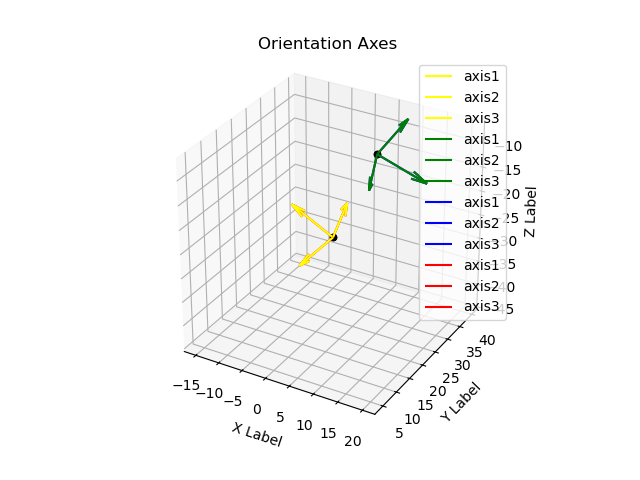

In [15]:
out_params = target_params
out_tcr_pose = get_axes(
    *[get_tcr_coords(out_design, np.array([chain])) for chain in out_params["tcr_chain_index"]]
    )
print(out_tcr_pose)
tcr_ref = get_tcr_ref(out_design, params)
out_tcr_pose = check_pose_direction(out_tcr_pose, get_tcr_ref(out_design, out_params))

mhc_positions = get_mhc1_positions(
    design=out_design,
    params=out_params,
    )
mhc_coords_0 = get_mhc_coords(
    design=out_design,
    positions=mhc_positions[:6])
mhc_coords_1 = get_mhc_coords(
    design=out_design,
    positions=mhc_positions[6:])

out_mhc_pose = get_axes(
    mhc_coords_0,
    mhc_coords_1
)
mhc_ref = get_mhc_ref(out_design, out_params)
out_mhc_pose = check_pose_direction(out_mhc_pose, get_mhc_ref(out_design, out_params))

x_factor=20
kwargs = dict(lim=(-1*x_factor,1*x_factor),plot_points=False, angle=None, normalize=.5*x_factor)#45*9)
fig = plt.figure()
ax = fig.add_subplot(projection='3d', )
ax.set_aspect("equal")
ax = plot_axes(axes=tcr_axes,center=tcr_center, ax=ax, **kwargs, color="yellow")
ax = plot_axes(axes=mhc_axes,center=mhc_center, ax=ax, **kwargs, color="green")
ax = plot_axes(*out_mhc_pose, ax=ax,**kwargs, color="blue")
ax = plot_axes(*out_tcr_pose, ax=ax,**kwargs, color="red")

In [17]:
out_design.save_pdb("test.pdb")

In [103]:
np.inner([-0.0323091,-0.61207544,0.79013905],[4.968793,-1.441082,8.885368])
def get_angle(a,b):
    return np.degrees(np.arccos(np.inner(a/np.linalg.norm(a), b/np.linalg.norm(b))))

Alignment score: 1082.0
target            0 -PHSMRYFETAVSRPGLEEPRYISVGYVDNKEFVRFDSDAENPRYEPRAPWMEQEGPEYW
                  0 -.||||||.|.|||||..|||.|.|||||...||||||||..||.||||||.||||||||
query             0 GSHSMRYFHTSVSRPGRGEPRFITVGYVDDTLFVRFDSDAASPREEPRAPWIEQEGPEYW

target           59 ERETQKAKGQEQWFRVSLRNLLGYYNQSAGGSHTLQQMSGCDLGSDWRLLRGYLQFAYEG
                 60 .||||..|...|..|..||.||.|||||..||||||.|.|||.|.|.||||||.|.||.|
query            60 DRETQISKAKAQTDREDLRTLLRYYNQSEAGSHTLQNMYGCDVGPDGRLLRGYHQDAYDG

target          119 RDYIALNEDLKTWTAADMAAQITRRKWEQSGAAEHYKAYLEGECVEWLHRYLKNGNATLL
                120 .|||||||||..|||||.|||||.||||....||...|||||||||||.|||.||..||.
query           120 KDYIALNEDLSSWTAADTAAQITQRKWEAARVAEQLRAYLEGECVEWLRRYLENGKETLQ

target          179 RTDSPKAHVTHHPRSKGEVTLRCWALGFYPADITLTWQLNGEELTQDMELVETRPAGDGT
                180 |.|.||.||||||.|..|.||||||||||||.||||||..||..|||.||||||||||.|
query           180 RADPPKTHVTHHPISDHEATLRCWALGFYPAEITLTWQRDGEDQTQDTELVETRPAGDRT



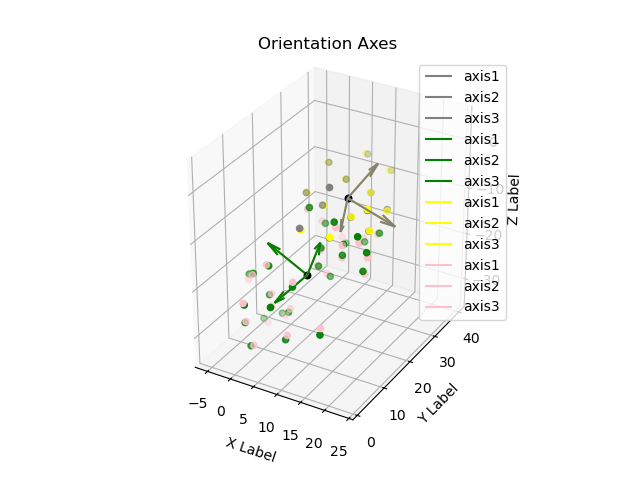

In [105]:
#mhc1_design = norm_design(mhc1_design)
#test_design = norm_design(test_design)

# test point relocation
mhc_positions = get_mhc1_positions(
    design=mhc1_design,
    params=params_1,
    )
print(",".join([str(c) for c in mhc_positions]))
mhc_coords_0 = get_mhc_coords(
    design=mhc1_design,
    positions=mhc_positions[:6])
mhc_coords_1 = get_mhc_coords(
    design=mhc1_design,
    positions=mhc_positions[6:])
a = (mhc_coords_0, mhc_coords_1)
a_ref = get_mhc_ref(mhc1_design, params_1)


b = (get_tcr_coords(mhc1_design, params_1["tcr_chain_index"][:1]),
    get_tcr_coords(mhc1_design, params_1["tcr_chain_index"][1:]))
b_ref = get_tcr_ref(mhc1_design, params_1)

c = (
    get_tcr_coords(test_design, test_params["tcr_chain_index"][:1]),
    get_tcr_coords(test_design, test_params["tcr_chain_index"][1:]),
    )

c_ref = get_tcr_ref(test_design, test_params)

mhc_positions = get_mhc1_positions(
    design=test_design,
    params=params_1,
    )
print(mhc_positions)


mhc_coords_0 = get_mhc_coords(
    design=test_design,
    positions=mhc_positions[:6])
mhc_coords_1 = get_mhc_coords(
    design=test_design,
    positions=mhc_positions[6:])
d = (mhc_coords_0, mhc_coords_1)
d_ref = get_mhc_ref(test_design, test_params)

print("d_ref: ",d_ref)
R_a, C_a = get_axes(a[0], a[1])
axis3, axis1 = check_direction(R_a[:,-1], C_a, a_ref, R_a[:,0])
R_a[:,-1] = axis3
R_a[:,0] = axis1
R_b, C_b = get_axes(b[0], b[1])
axis3, axis1 = check_direction(R_b[:,-1], C_b, b_ref, R_b[:,0])
R_b[:,-1] = axis3
R_b[:,0] = axis1
R_c, C_c = get_axes(c[0], c[1])
axis3, axis1 = check_direction(R_c[:,-1], C_c, c_ref, R_c[:,0])
R_c[:,-1] = axis3
R_c[:,0] = axis1
R_d, C_d = get_axes(d[0], d[1])
axis3, axis1 = check_direction(R_d[:,-1], C_d, d_ref, R_d[:,0])
R_d[:,-1] = axis3
R_d[:,0] = axis1

# align TCRs
align_op = get_ax_op(
    R_c, C_c,
    R_b, C_b
)
c = apply_atom_op(np.concatenate(c), op=align_op).squeeze()
c_ref = apply_atom_op(c_ref, op=align_op)[None,...]
# separate again
c = (c[:13],c[13:])
# recompute axes
R_c, C_c = get_axes(c[0], c[1])
axis3, axis1 = check_direction(R_c[:,-1], C_c, c_ref, R_c[:,0])
R_c[:,-1] = axis3
R_c[:,0] = axis1

#align mhc
align_op = get_ax_op(
    R_d, C_d,
    R_a, C_a
)
d = apply_atom_op(np.concatenate(d), op=align_op).squeeze()
d_ref = apply_atom_op(d_ref, op=align_op)[None,...]
print("d_ref: ",d_ref)
# separate again
d = (d[:6],d[6:])
# recompute axes
R_d, C_d = get_axes(d[0], d[1])
axis3, axis1 = check_direction(R_d[:,-1], C_d, d_ref, R_d[:,0])
R_d[:,-1] = axis3
R_d[:,0] = axis1



#c_b = apply_atom_op(np.concatenate(c), op=align_op).squeeze()
#c_ref_b = apply_atom_op(np.concatenate(c_ref), op=align_op).squeeze()
## separate again
#c_b = (c_b[:13],c_b[13:])
#R_c_b, C_c_b = get_axes(c_b[0], c_b[1])
#axis3, axis1 = check_direction(R_c_b[:,-1], C_c_b, c_ref_b, R_c_b[:,0])
#R_c_b[:,-1] = axis3

print("TCR-Angles: ",*[get_angle(R_c[:,n], R_b[:,n])for n in range(3)], sep="\n")
#print("TCR-Angles: (aligned) ",*[get_angle(R_c_b[:,n], R_b[:,n])for n in range(3)], sep="\n")
print("MHC-Angles: ",*[get_angle(R_d[:,n], R_a[:,n])for n in range(3)], sep="\n")

op = get_ax_op(
    R_b, C_b,
    R_a, C_a,
    )
# apply to concatenated points
b1 = apply_atom_op(np.concatenate(b), op=op).squeeze()
# separate again
b1 = (b1[:13],b1[13:])

op = get_ax_op(
    R_c, C_c,
    R_d, C_d,
    )
# apply to concatenated points
c1 = apply_atom_op(np.concatenate(c), op=op).squeeze()
# separate again
c1 = (c1[:13],c1[13:])

op = get_ax_op(
    R_c, C_c,
    R_d, C_d,
    )

b2 = rev_atom_op(np.concatenate(b1), op=op)
b2 = (b2[:13],b2[13:])
xfactor=20
kwargs = dict(lim=(-1*xfactor,1*xfactor),plot_points=True, angle=None, normalize=0.5*xfactor)#45*9)
fig = plt.figure()
ax = fig.add_subplot(projection='3d', )
plot_axes(a=a[0], b=a[1], ax=ax, **kwargs, ref=a_ref, color="gray")
#ax.scatter(*a_ref.mean(axis=(0,1)), color="gray")
plot_axes(a=b[0], b=b[1], ax=ax, **kwargs, ref=b_ref, color="green")
#ax.scatter(*b_ref.T, color="green")
##ax.scatter(*a_ref.reshape(-1,3).T, color=False)
##ax.scatter(*b_ref.reshape(-1,3).T, color="blue")


#print(b_ref.mean(axis=(0,1))-C_b)
#ax.quiver(*C_b, *(b_ref.mean(axis=(0,1))-C_b), color=False)

plot_axes(a=d[0], b=d[1], ax=ax, **kwargs, ref=d_ref, color="yellow")
#ax.scatter(*d_ref.T, color="yellow")
plot_axes(a=c[0], b=c[1], ax=ax, **kwargs, ref=c_ref, color="pink")
#ax.scatter(*c_ref.T, color="pink")
ax.set_aspect("equal")
#plot_axes(a=c_b[0], b=c_b[1], ax=ax, **kwargs, ref=c_ref_b, color=False)
#ax.scatter(*c_b_ref.mean(axis=(0,1)), color="pink")
#plot_axes(a=b1[0], b=b1[1], ax=ax, color=False, **kwargs, )
#plot_axes(a=c1[0], b=c1[1], ax=ax, color=False, **kwargs, )
#plot_axes(a=b2[0], b=b2[1], ax=ax, **kwargs, color=False)
#ax.scatter(0,0,0, color=False, depthshade=False)

NameError: name '_center_atom_op' is not defined

New plot axis
Calculating Axes
Before correction:  [-0.3667357   0.43059444 -0.82467773] [ 0.89812401 -0.06733639 -0.43455619]
Correcting to [ 0.50976145 -0.39003957  0.76681966]
Angle is 170.85010033138943
After correction:  [ 0.3667357  -0.43059444  0.82467773] [-0.89812401  0.06733639  0.43455619]


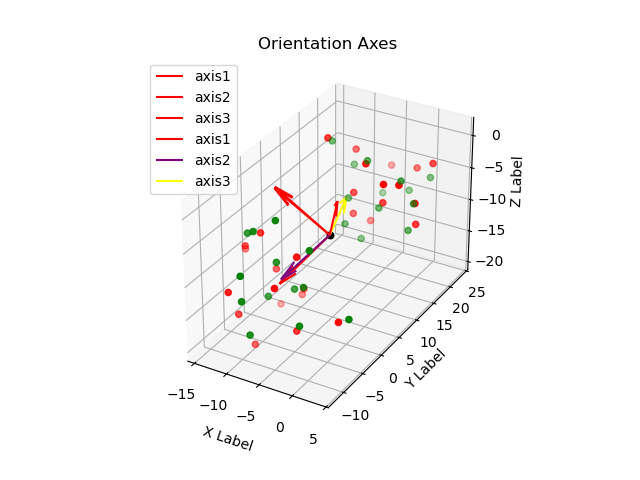

In [51]:
mhc_1 = R_a, C_a
tcr_1 = R_b, C_b
mhc_2 = R_d, C_d
tcr_2 = R_c, C_c

def align_to_mhc(tcr_frame, target_frame, target_positions):
    #op = get_ax_op(
    #    *target_frame,
    #    *tcr_frame
    #)
    #return apply_atom_op(target_positions, op)
    R_tcr, T_tcr = tcr_frame
    R_target, T_target = target_frame
    target_positions = target_positions.squeeze()
    return np.einsum("ij,jk,...k->...i", R_tcr, R_target.T, (target_positions - T_target)) + T_tcr

# b<-c
kwargs.update(plot_points=True)
c_2 = align_to_mhc(tcr_1, tcr_2, np.concatenate(c))
c_2_ref = align_to_mhc(tcr_1, tcr_2, np.concatenate(c_ref))
ax = plot_axes(a=c_2[:13], b=c_2[13:], **kwargs, ref=c_2_ref, color="red", )
ax.scatter(*np.concatenate(b).T, color="green")
plot_axes(*tcr_1, **kwargs, color=False, ax=ax, )
ax.set_aspect("equal")

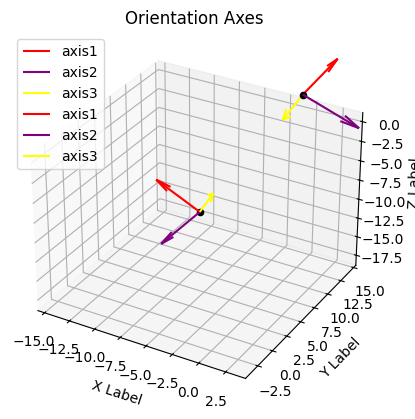

In [94]:
fig

New plot axis


array([[ True,  True, False],
       [ True,  True, False],
       [ True,  True, False]])

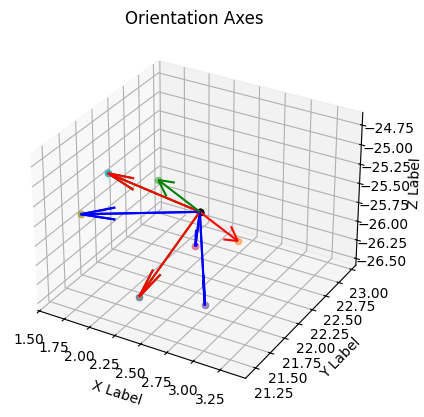

In [14]:
new_axes, new_center = rev_ax_op(axes,center,op1)
ax = plot_axes(axes=tcr_axes,center=tcr_center, color="green", lim=(-1,1))
ax = plot_axes(axes=mhc_axes,center=tcr_center, color="blue", ax=ax, lim=(-1,1))
ax = plot_axes(axes=axes,center=tcr_center, color="blue", ax=ax, lim=(-1,1))
ax = plot_axes(axes=new_axes,center=new_center, color="red", ax=ax, lim=(-1,1))

np.isclose(new_axes,tcr_axes)

In [15]:

d = get_centering(tcr_center, mhc_center)
tcr_center_c = tcr_center - d
print(tcr_center, tcr_center_c, mhc_center)

[  2.484077  22.082233 -25.590542] [17.060333   11.7215     -0.01824951] [17.060333   11.7215     -0.01824999]


New plot axis


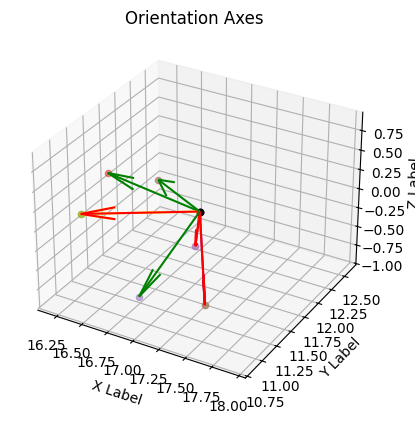

In [16]:
def rotate_axis(axes1, axes2):
    rot1 = Rotation.from_matrix(axes1)
    rot2 = Rotation.from_matrix(axes2)
    return rot2.apply(axes1.T@axes1, inverse=True)
tcr_axes_r = rotate_axis(tcr_axes, mhc_axes)
 #= r.apply(tcr_axes)
ax = plot_axes(axes=mhc_axes, center=mhc_center,)
ax = plot_axes(axes=tcr_axes,center=tcr_center_c, color="green", ax=ax,)
ax = plot_axes(axes=tcr_axes_r,center=tcr_center_c, color="red", ax=ax,)


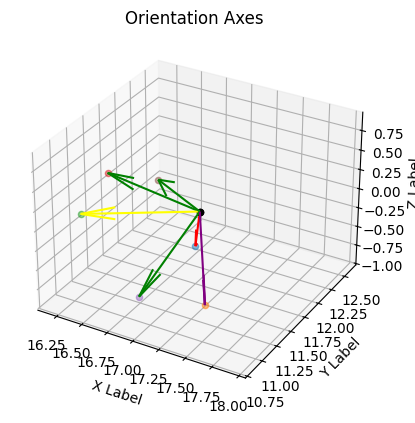

In [17]:
fig= plt.figure()
ax = fig.add_subplot(projection="3d")
yax = plot_axes(axes=mhc_axes, center=mhc_center, ax=ax, lim=(-1,1))
ax = plot_axes(axes=tcr_axes,center=tcr_center_c, color="green", ax=ax, lim=(-1,1))

In [18]:
test_axes_operations(
    axes1=tcr_axes,
    center1=tcr_center,
    axes2=mhc_axes,
    center2=mhc_center,
    get_ax_op=get_ax_op,
    apply_ax_op=apply_ax_op)

In [19]:
tmp.cleanup()

In [20]:
def _data_to_pos(x):
    if hasattr(x, "to_data"):
        x = x.to_data()
        assert isinstance(x, DesignData)
    if isinstance(x, DesignData):
        x = x["atom_positions"]
    return x
def order_chains(design:DesignData, order:np.ndarray):
    parts = []
    for chain in order:
        parts.append(design["chain_index"]==chain)
    return DesignData.concatenate([design[part] for part in parts], sep_chains=False)

def convert_chains(input_design:DesignData, d:dict|None=None):
    if d is None:
        d = {}
        for x,y in zip(np.sort(np.unique(input_design["chain_index"])), range(len(np.unique(input_design["chain_index"])))):
            d[int(x)]=int(y)
    print(d)
    design = input_design.update(chain_index=np.array([d[int(x)] for x in input_design["chain_index"]]))
    return design, d

def align(x:DesignData, y:DesignData, on_chain:str|int|list[str|int]):
    
    # convert chains to concrete integer range
    y,d = convert_chains(y)
    x,_ = convert_chains(x, d=d)

    on_chain=d[on_chain]

    # bring chains of x in same order
    y_chain_order = np.unique(y["chain_index"])
    x = order_chains(x, y_chain_order)

    # get chain mask
    on_chain = np.array(list(on_chain))
    chain_mask_x = (x["chain_index"][:,None]==on_chain[None,:]).any(axis=1)
    chain_mask_y = (y["chain_index"][:,None]==on_chain[None,:]).any(axis=1)

    # convert to 3d coordinates
    x = _data_to_pos(x)
    y = _data_to_pos(y)

    #

    return x